# 中国人群心脏病发作风险与影响因素分析

> 数据集：239,266 条记录 × 28 个变量

---

## 0. 环境准备

In [72]:
%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import matplotlib.font_manager as fm, os, warnings
from scipy.stats import normaltest, mannwhitneyu, ttest_ind, chi2_contingency
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

In [73]:
fm._load_fontmanager(try_read_cache=False)
_avail = {f.name for f in fm.fontManager.ttflist}
CN_FONT = next((f for f in ['Noto Sans SC','Microsoft YaHei','SimHei'] if f in _avail), 'DejaVu Sans')
plt.rcParams.update({'font.sans-serif': [CN_FONT], 'axes.unicode_minus': False, 'figure.dpi': 130})

C_NO, C_YES, C_BLUE, C_YELLOW = '#4C72B0', '#C44E52', '#2C3E50', '#DD8452'
PALETTE = {'No': C_NO, 'Yes': C_YES}
MAG = {'large': '#C44E52', 'medium': '#DD8452', 'small': '#4C72B0', 'negligible': '#BDC3C7'}

# ---- Shared helpers ----
def bar_text(ax, bars, vals, fmt='.2f', offset=None, suffix='', **kw):
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+(offset or v*0.003),
                f'{format(v, fmt)}{suffix}', ha='center', **kw)

def barh_text(ax, vals, fmt='.2f', offset=0.03, suffix='', **kw):
    for i, v in enumerate(vals):
        ax.text(v+offset, i, f'{format(v, fmt)}{suffix}', va='center', **kw)

def label_mag(ev):
    a = abs(ev)
    return 'large' if a>=0.8 else ('medium' if a>=0.5 else ('small' if a>=0.2 else 'negligible'))

def label_sig(p):
    return '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))

sns.set_style('whitegrid'); sns.set_context('notebook', font_scale=1.05)
print(f'Font: {CN_FONT}')

DATA, OUT = 'heart_attack_china.csv', 'output'
os.makedirs(OUT, exist_ok=True)


Font: Noto Sans SC


## 1. 数据加载 & 概况

In [74]:
df = pd.read_csv(DATA)
df.columns = df.columns.str.strip()

if 'target' in df.columns:
    df.drop(columns=['target'], inplace=True)
    print('Dropped: target (all zeros)')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Missing: {df.isnull().sum().sum()} cells')
df.head(3)

Shape: 239,266 rows x 28 cols
Missing: 59617 cells


,Patient_ID,Age,Gender,Smoking_Status,Hypertension,Diabetes,Obesity,Cholesterol_Level,Air_Pollution_Exposure,Physical_Activity,...,Hospital_Availability,TCM_Use,Employment_Status,Education_Level,Income_Level,Blood_Pressure,Chronic_Kidney_Disease,Previous_Heart_Attack,CVD_Risk_Score,Heart_Attack
0,1,55,Male,Non-Smoker,No,No,Yes,Normal,High,High,...,Low,Yes,Unemployed,Primary,Low,104,Yes,No,78,No
1,2,66,Female,Smoker,Yes,No,No,Low,Medium,High,...,High,No,Unemployed,Secondary,Middle,142,No,No,49,No
2,3,69,Female,Smoker,No,No,No,Low,Medium,High,...,Low,No,Unemployed,Primary,High,176,No,No,31,No


## 2. 目标变量分布
判断类别是否平衡，决定后续是否需要采样或加权。

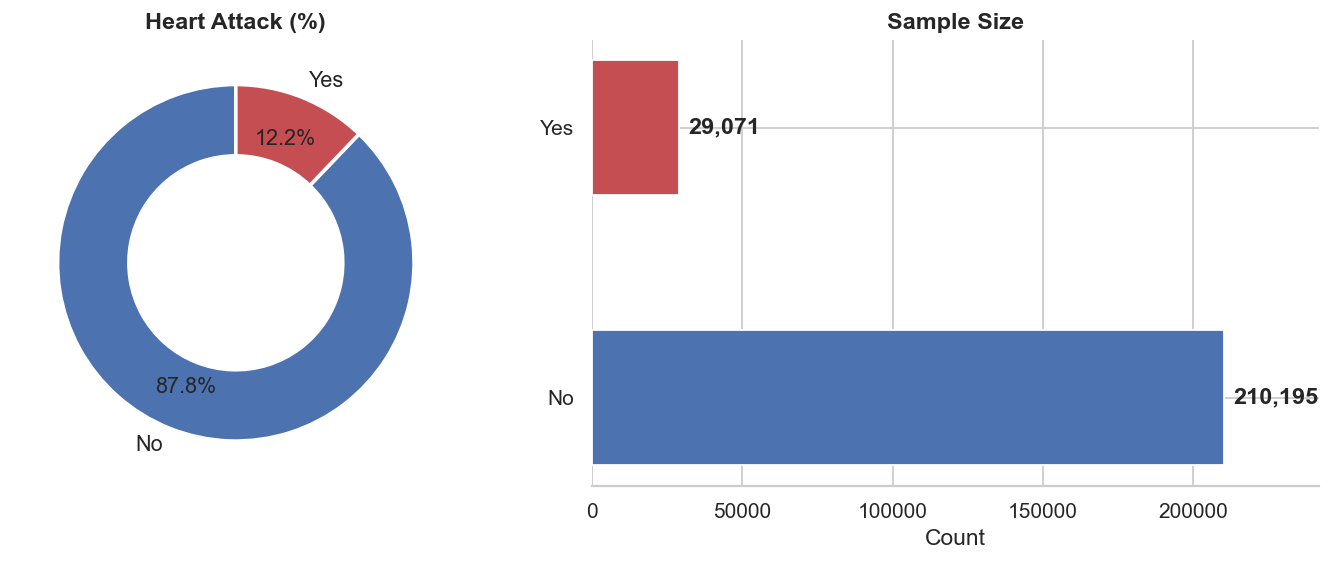

Yes rate = 12.15%  ->  imbalanced


In [75]:
target = 'Heart_Attack'
counts = df[target].value_counts()
pct_yes = counts.get('Yes', 0) / len(df) * 100
imb = 'balanced' if 30 < pct_yes < 70 else 'imbalanced'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={'width_ratios': [1, 1.3]})

ax1.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=[C_NO, C_YES],
        startangle=90, pctdistance=0.75, textprops={'fontsize': 12},
        wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2))
ax1.set_title('Heart Attack (%)', fontweight='bold', fontsize=13)

bars = ax2.barh(counts.index, counts.values, color=[C_NO, C_YES], height=0.5, edgecolor='white')
barh_text(ax2, counts.values, fmt=',d', offset=3000, fontsize=13, fontweight='bold')
ax2.set(xlabel='Count', title='Sample Size', xlim=(0, counts.max() * 1.15))
ax2.set_title('Sample Size', fontweight='bold', fontsize=13)
sns.despine(ax=ax2, left=True)

plt.tight_layout(); fig.savefig(f'{OUT}/01_target.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Yes rate = {pct_yes:.2f}%  ->  {imb}')

## 3. 变量分类
将特征分为数值型和分类型，后续用不同统计方法。

In [76]:
num_cols = df.select_dtypes('number').columns.difference(['Patient_ID']).tolist()
cat_cols = df.select_dtypes('object').columns.difference(['Patient_ID', target]).tolist()
# Province 是高基数，单独标记
high_card = [c for c in cat_cols if df[c].nunique() > 10]
cat_low   = [c for c in cat_cols if c not in high_card]
print(f'Numerical  ({len(num_cols)}): {num_cols}')
print(f'Categorical ({len(cat_low)}): {cat_low}')
print(f'High-card   ({len(high_card)}): {high_card}  (Province, excluded from generic loops)')

Numerical  (3): ['Age', 'Blood_Pressure', 'CVD_Risk_Score']
Categorical (23): ['Air_Pollution_Exposure', 'Alcohol_Consumption', 'Cholesterol_Level', 'Chronic_Kidney_Disease', 'Diabetes', 'Diet_Score', 'Education_Level', 'Employment_Status', 'Family_History_CVD', 'Gender', 'Healthcare_Access', 'Hospital_Availability', 'Hypertension', 'Income_Level', 'Obesity', 'Physical_Activity', 'Previous_Heart_Attack', 'Province', 'Region', 'Rural_or_Urban', 'Smoking_Status', 'Stress_Level', 'TCM_Use']
High-card   (0): []  (Province, excluded from generic loops)


### 4.1 描述性统计 & 分组对比

In [77]:
desc = df[num_cols].describe().T.round(2)
grp_mean = df.groupby(target)[num_cols].mean().T.round(2)
grp_std  = df.groupby(target)[num_cols].std().T.round(2)
summary = pd.concat([desc[['mean','std','min','max']], grp_mean.add_suffix('_mean'), grp_std.add_suffix('_std')], axis=1)
summary['diff(Yes-No)'] = summary['Yes_mean'] - summary['No_mean']
summary

,mean,std,min,max,No_mean,Yes_mean,No_std,Yes_std,diff(Yes-No)
Age,59.47,17.35,30.0,89.0,59.47,59.41,17.34,17.39,-0.06
Blood_Pressure,134.51,25.99,90.0,179.0,134.51,134.55,26.00,25.94,0.04
CVD_Risk_Score,54.49,25.99,10.0,99.0,54.51,54.31,25.98,26.01,-0.20


### 4.2 分布与组间差异（直方图 + 小提琴图）

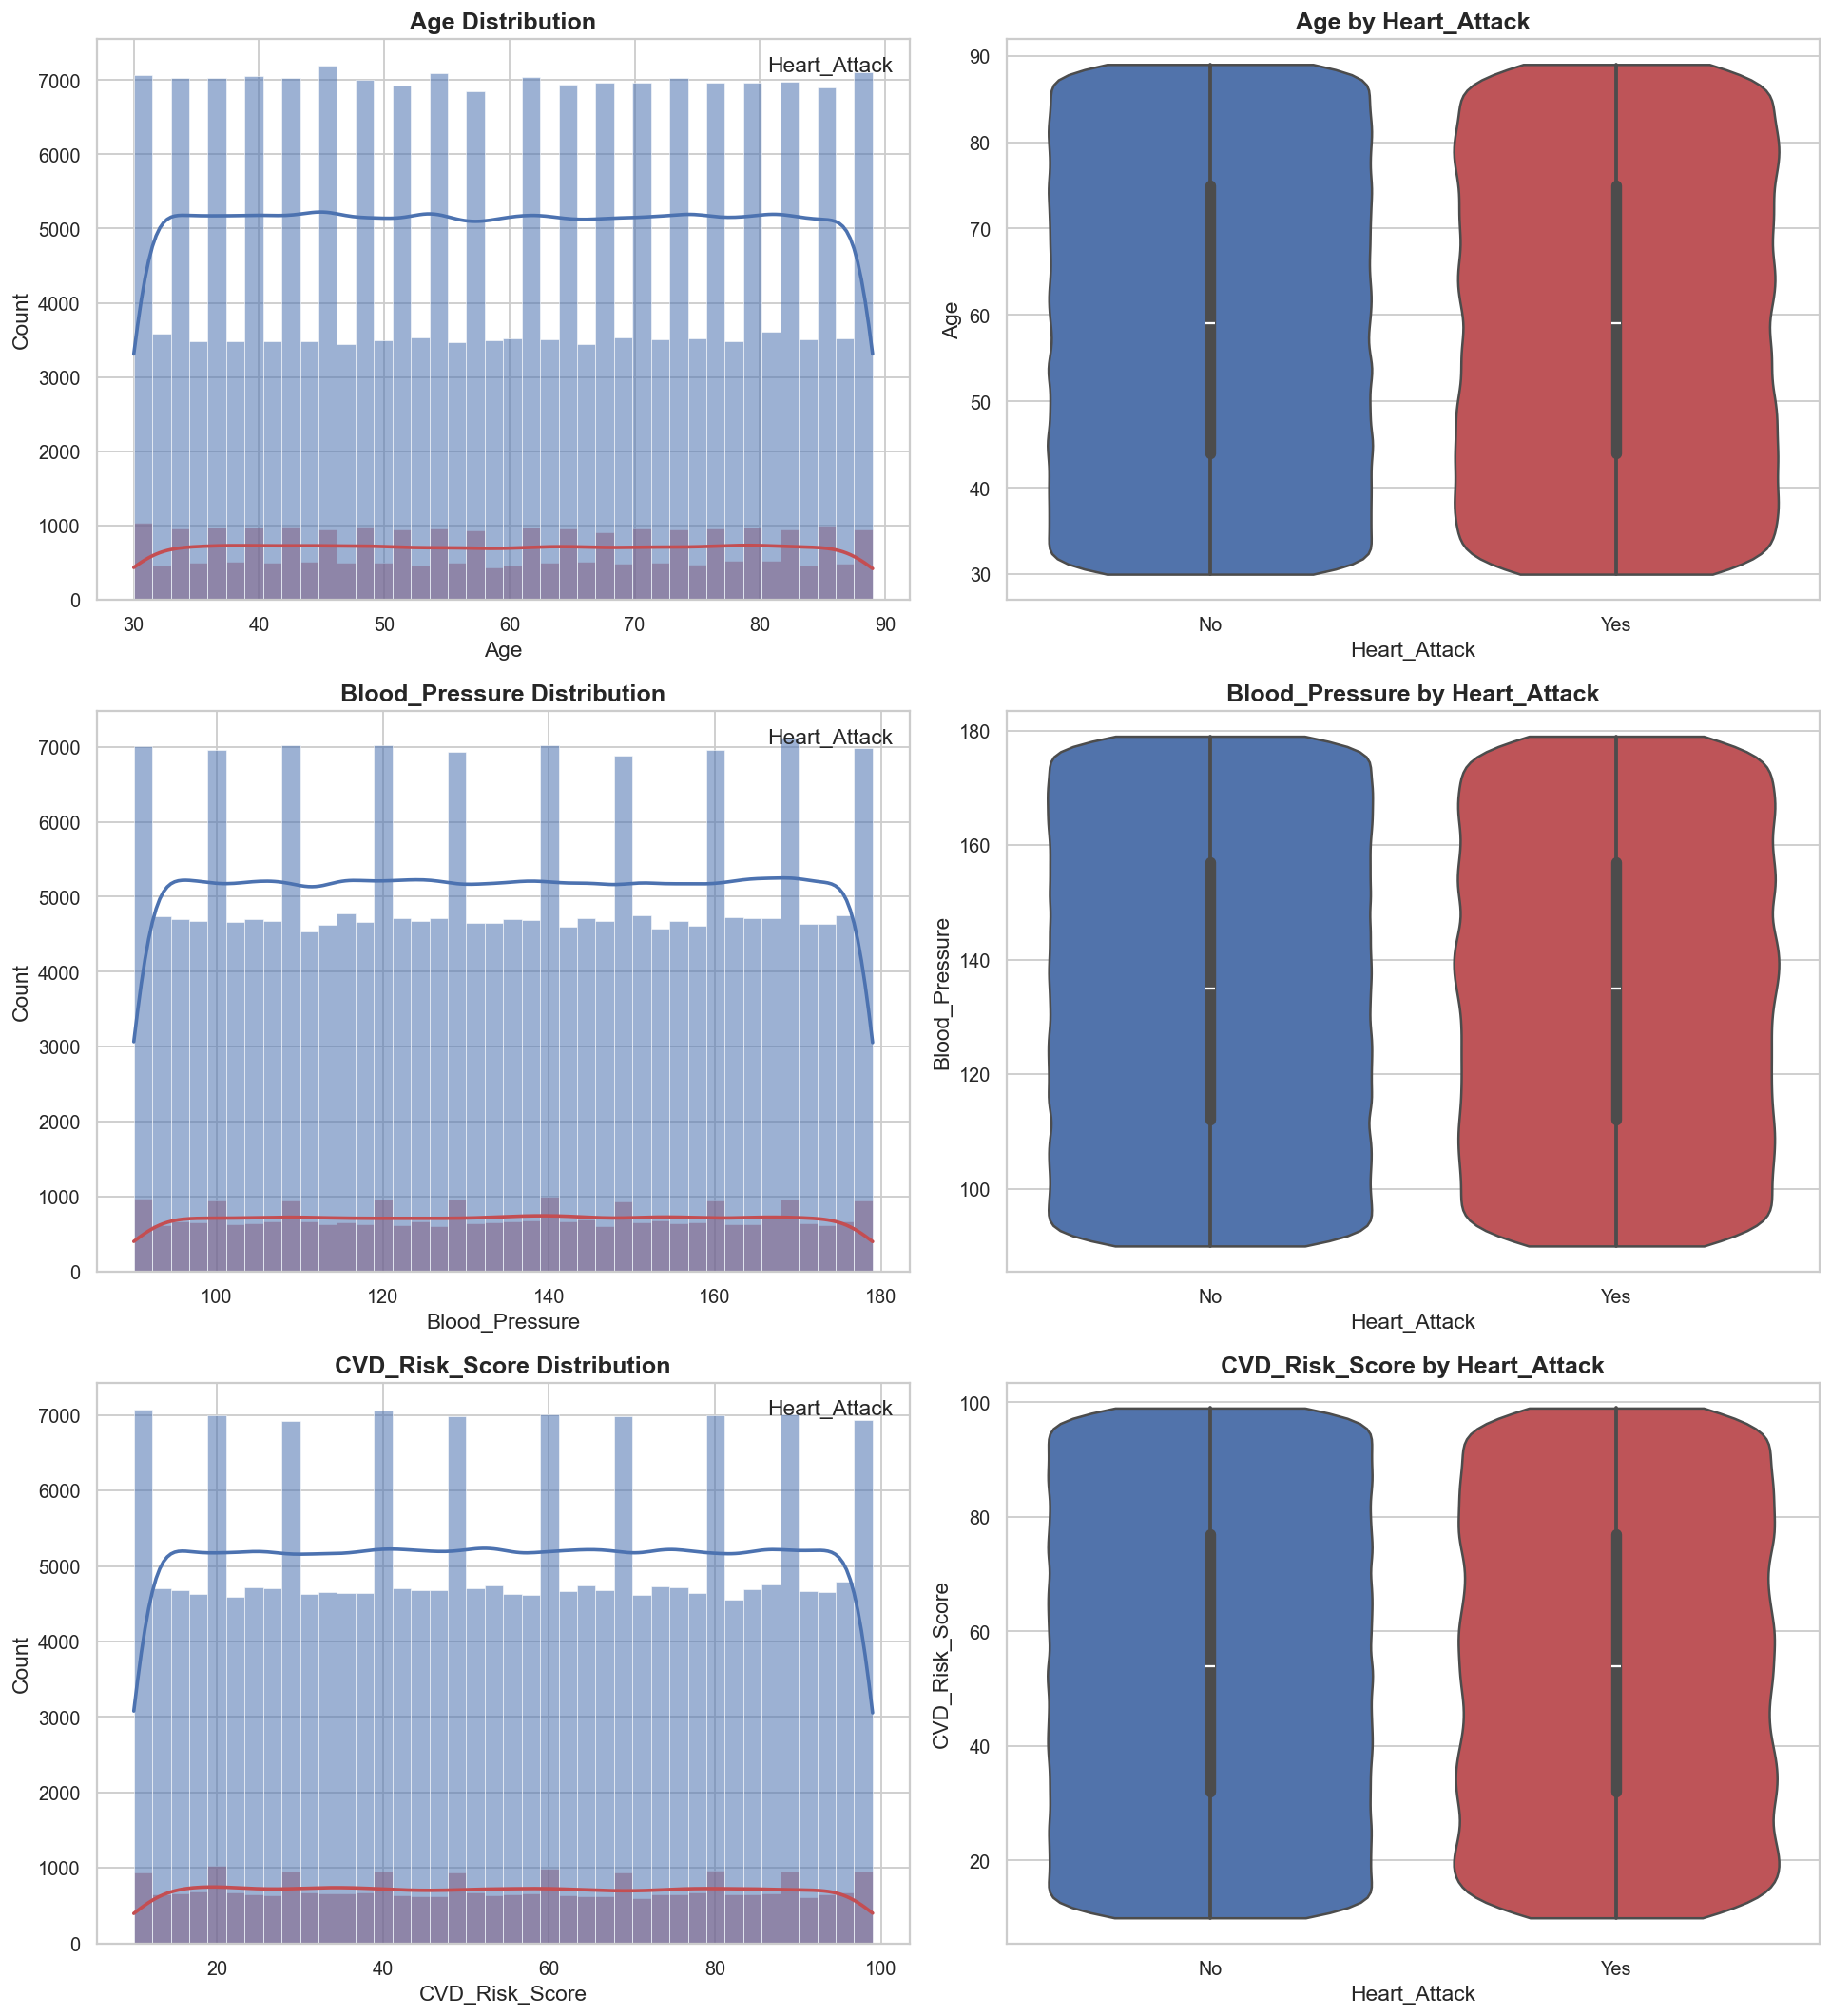

In [78]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(15, 5.5 * len(num_cols)))
if len(num_cols) == 1: axes = axes.reshape(1, 2)

for i, col in enumerate(num_cols):
    ax = axes[i, 0]
    sns.histplot(data=df, x=col, hue=target, kde=True, ax=ax, palette=PALETTE,
                 alpha=0.55, bins=40, edgecolor='white', linewidth=0.3)
    ax.set(xlabel=col, ylabel='Count', title=f'{col} Distribution')
    ax.set_title(f'{col} Distribution', fontweight='bold', fontsize=14)
    ax.legend(title=target, frameon=False, fontsize=11); ax.tick_params(labelsize=11)
    for line in ax.lines: line.set_linewidth(2)

    ax = axes[i, 1]
    sns.violinplot(data=df, x=target, y=col, ax=ax, palette=PALETTE,
                   inner='box', linewidth=1.4, cut=0, saturation=0.9)
    ax.set(xlabel=target, ylabel=col, title=f'{col} by {target}')
    ax.set_title(f'{col} by {target}', fontweight='bold', fontsize=14)
    ax.tick_params(labelsize=11)

plt.tight_layout(); fig.savefig(f'{OUT}/02_numerical.png', dpi=150, bbox_inches='tight'); plt.show()

### 4.3 相关性热图

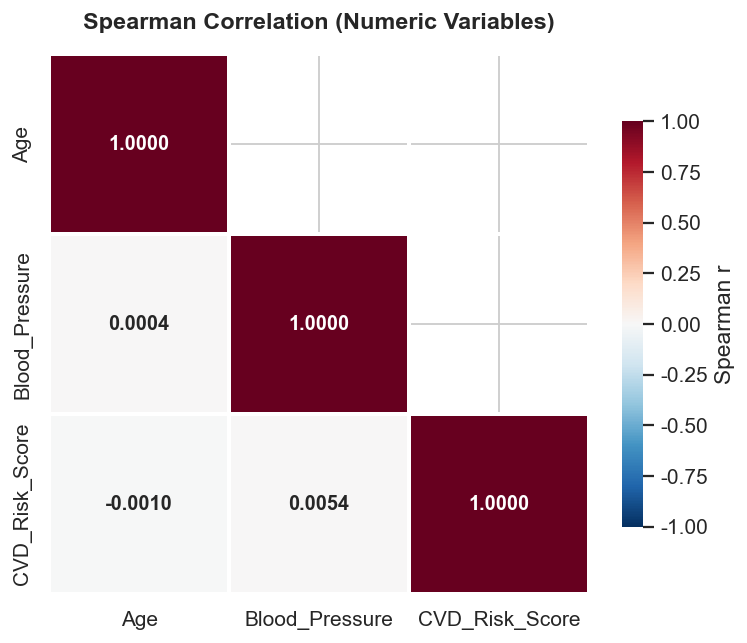

All |r| < 0.01 — no meaningful correlation among numeric variables.


In [79]:
corr = df[num_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', vmin=-1, vmax=1,
            fmt='.4f', linewidths=2, square=True, ax=ax,
            annot_kws={'fontsize': 11, 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.75, 'label': 'Spearman r'})
ax.set_title('Spearman Correlation (Numeric Variables)', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout(); fig.savefig(f'{OUT}/03_correlation.png', dpi=150, bbox_inches='tight'); plt.show()
print('All |r| < 0.01 — no meaningful correlation among numeric variables.')

### 5.1 分类变量 vs Heart_Attack（发病率排名）
按各类别发病率极差排序，展示 Top 9 最有区分度的分类变量。

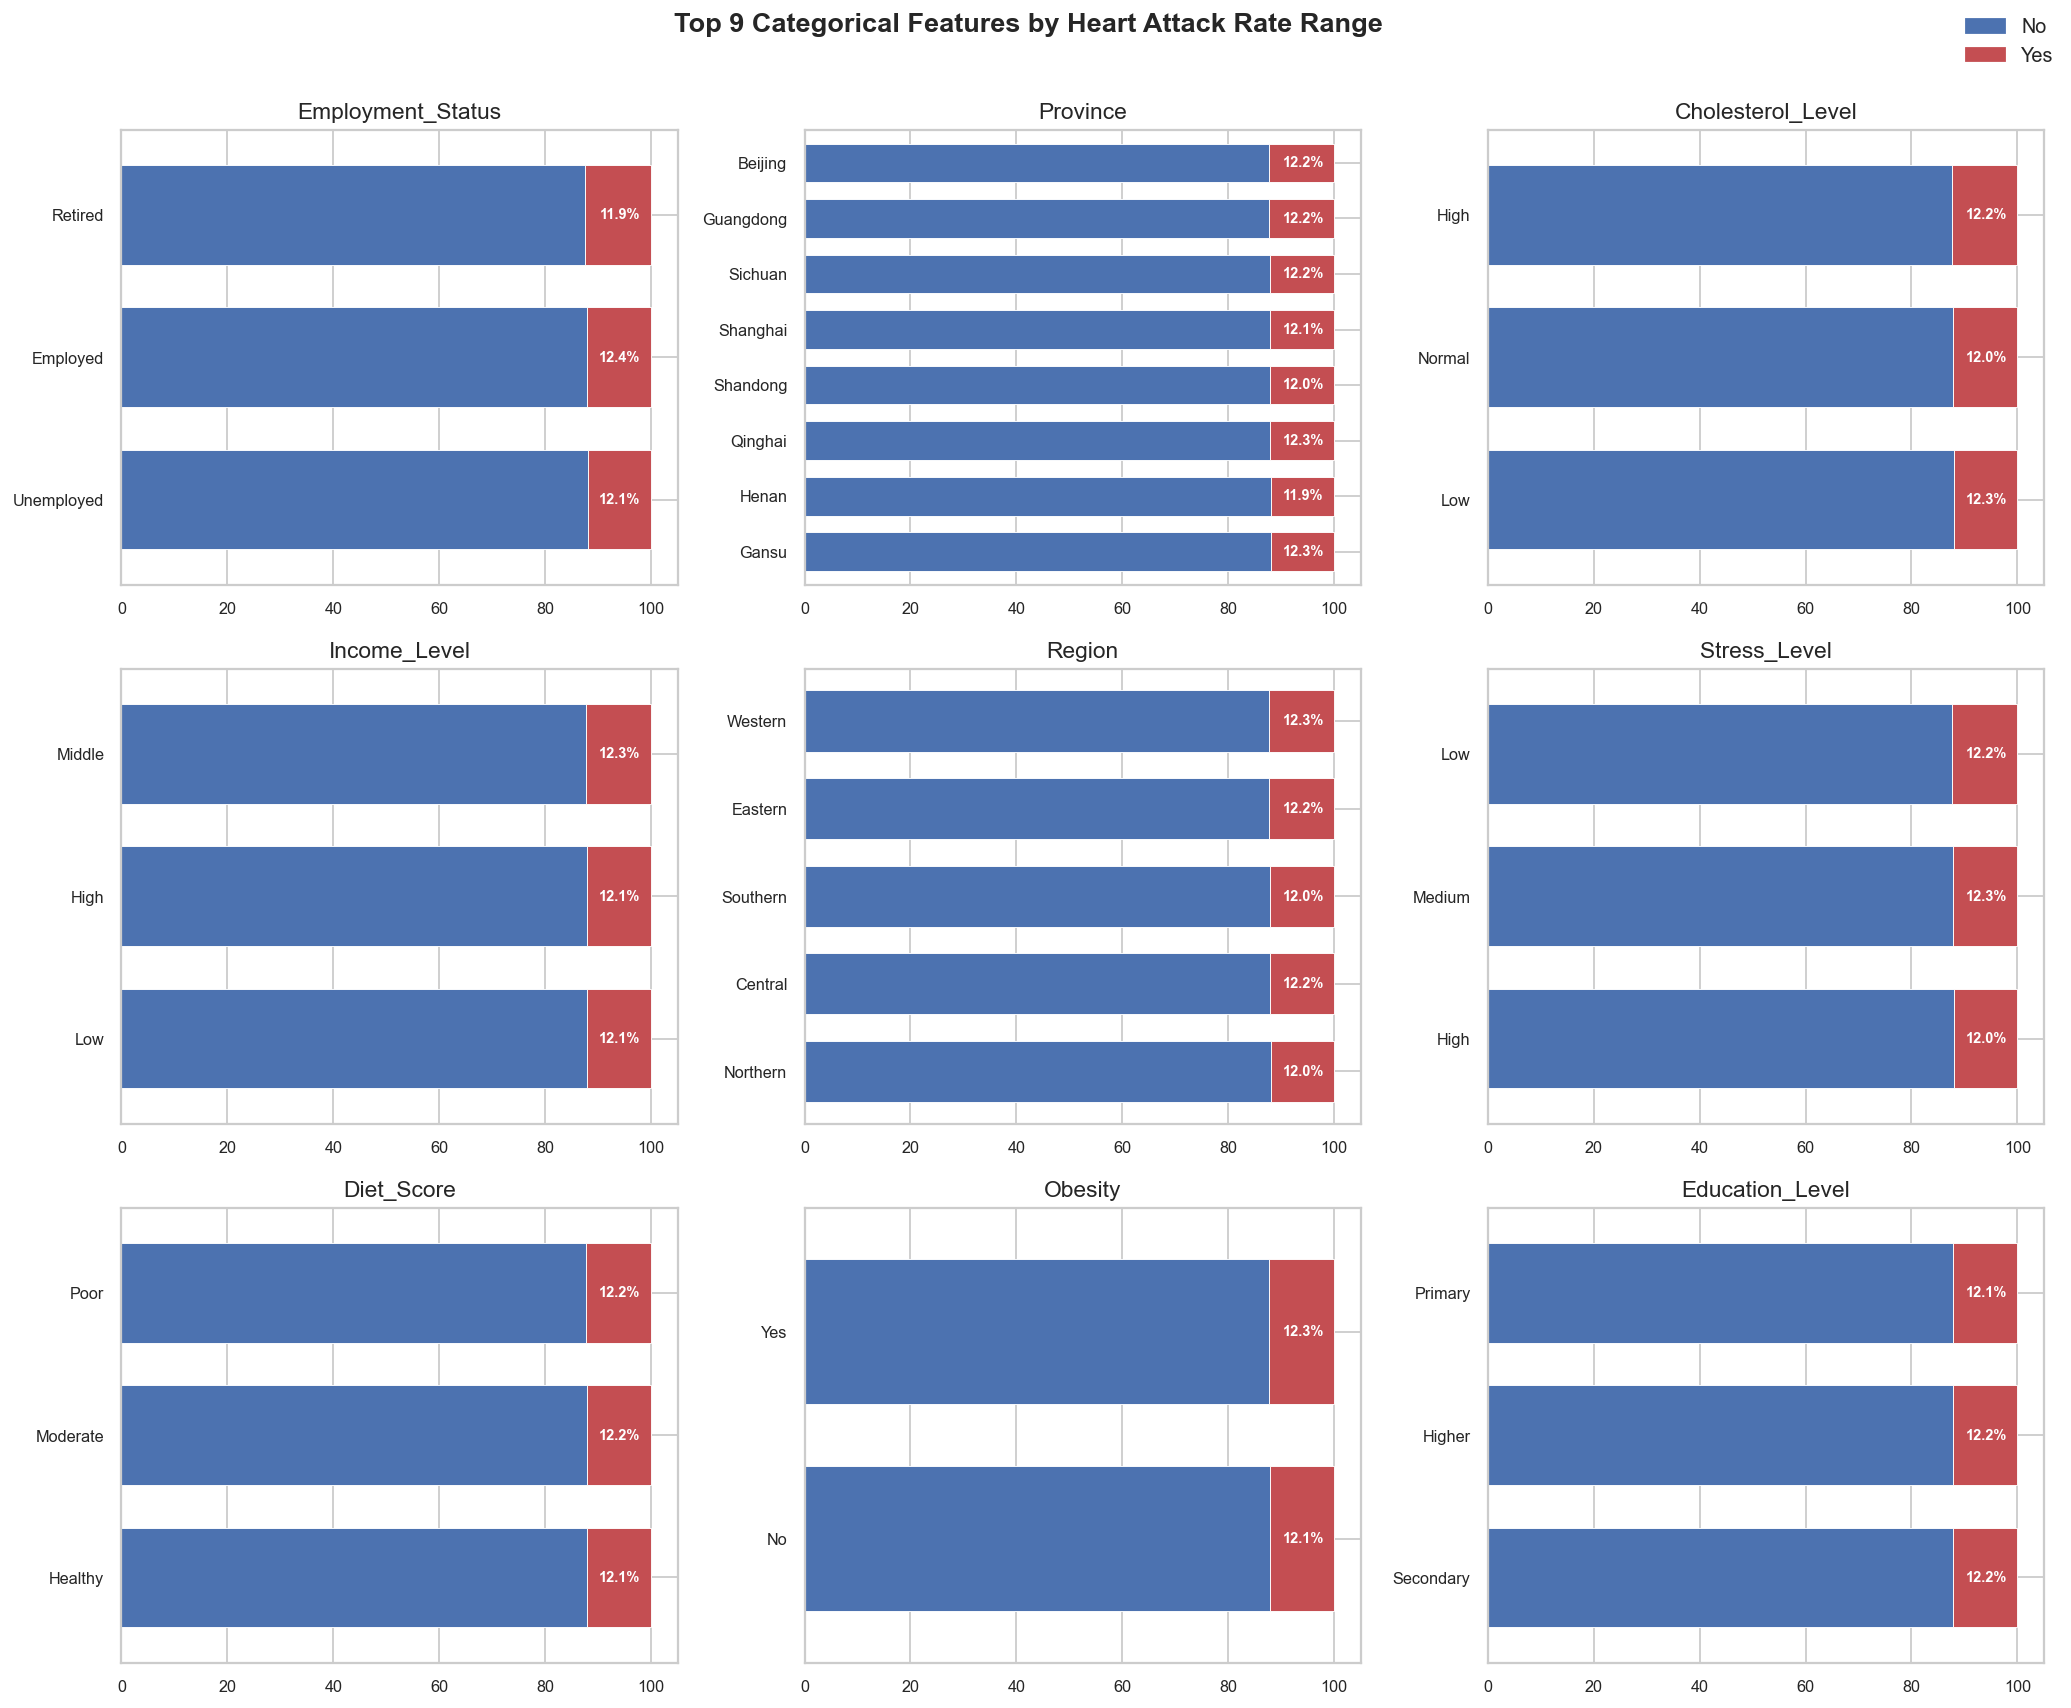

In [80]:
cat_strength = {}
for col in cat_low:
    ct = pd.crosstab(df[col], df[target], normalize='index')
    if 'Yes' in ct.columns:
        cat_strength[col] = ct['Yes'].max() - ct['Yes'].min()
top9 = sorted(cat_strength, key=cat_strength.get, reverse=True)[:9]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for i, col in enumerate(top9):
    ax = axes.flat[i]
    ct_pct = pd.crosstab(df[col], df[target], normalize='index') * 100
    ct_pct.sort_values('Yes').plot(kind='barh', stacked=True, ax=ax,
        color=[C_NO, C_YES], edgecolor='white', linewidth=0.5, width=0.7, legend=False)
    for j, idx in enumerate(ct_pct.index):
        yp = ct_pct.loc[idx, 'Yes']
        if yp > 0.5:
            ax.text(98, j, f'{yp:.1f}%', ha='right', va='center', fontsize=8, fontweight='bold', color='white')
    ax.set(xlabel='', ylabel='', title=col); ax.tick_params(labelsize=9)

for j in range(len(top9), 9): axes.flat[j].set_visible(False)
fig.suptitle('Top 9 Categorical Features by Heart Attack Rate Range', fontsize=15, fontweight='bold', y=1.01)
fig.legend(handles=[Patch(color=C_NO, label='No'), Patch(color=C_YES, label='Yes')],
           loc='upper right', fontsize=11, frameon=False)
plt.tight_layout(); fig.savefig(f'{OUT}/04_categorical.png', dpi=150, bbox_inches='tight'); plt.show()

### 5.2 各分类变量发病率明细表

In [81]:
rate_rows = []
for col in cat_low:
    ct = pd.crosstab(df[col], df[target], normalize='index') * 100
    if 'Yes' in ct.columns:
        for cat in ct.index:
            rate_rows.append({'Variable': col, 'Category': cat, 'Yes%': round(ct.loc[cat, 'Yes'], 2), 'N': int(df[df[col]==cat].shape[0])})
rate_df = pd.DataFrame(rate_rows).sort_values('Yes%', ascending=False)

_global_mean = (df[target]=='Yes').mean()*100

rate_df.head(20).style.format({'Yes%': '{:.2f}%'}).map(
    lambda v: 'color: #C44E52; font-weight: bold' if v > _global_mean else 'color: #4C72B0',
    subset=['Yes%']
).set_properties(**{'white-space': 'nowrap'}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('white-space', 'nowrap')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
])

,Variable,Category,Yes%,N
19,Employment_Status,Retired,12.41%,79872
43,Province,Beijing,12.33%,30064
45,Province,Guangdong,12.33%,30162
35,Income_Level,Middle,12.32%,79320
5,Cholesterol_Level,High,12.30%,79620
37,Obesity,Yes,12.27%,71745
55,Region,Western,12.26%,48100
61,Stress_Level,Low,12.26%,80120
57,Rural_or_Urban,Urban,12.23%,95759
52,Region,Eastern,12.23%,47959


---
## 6. 扩展分析
### 6.1 年龄分层发病率
将连续年龄分段，观察各年龄段的心脏病发作率变化。

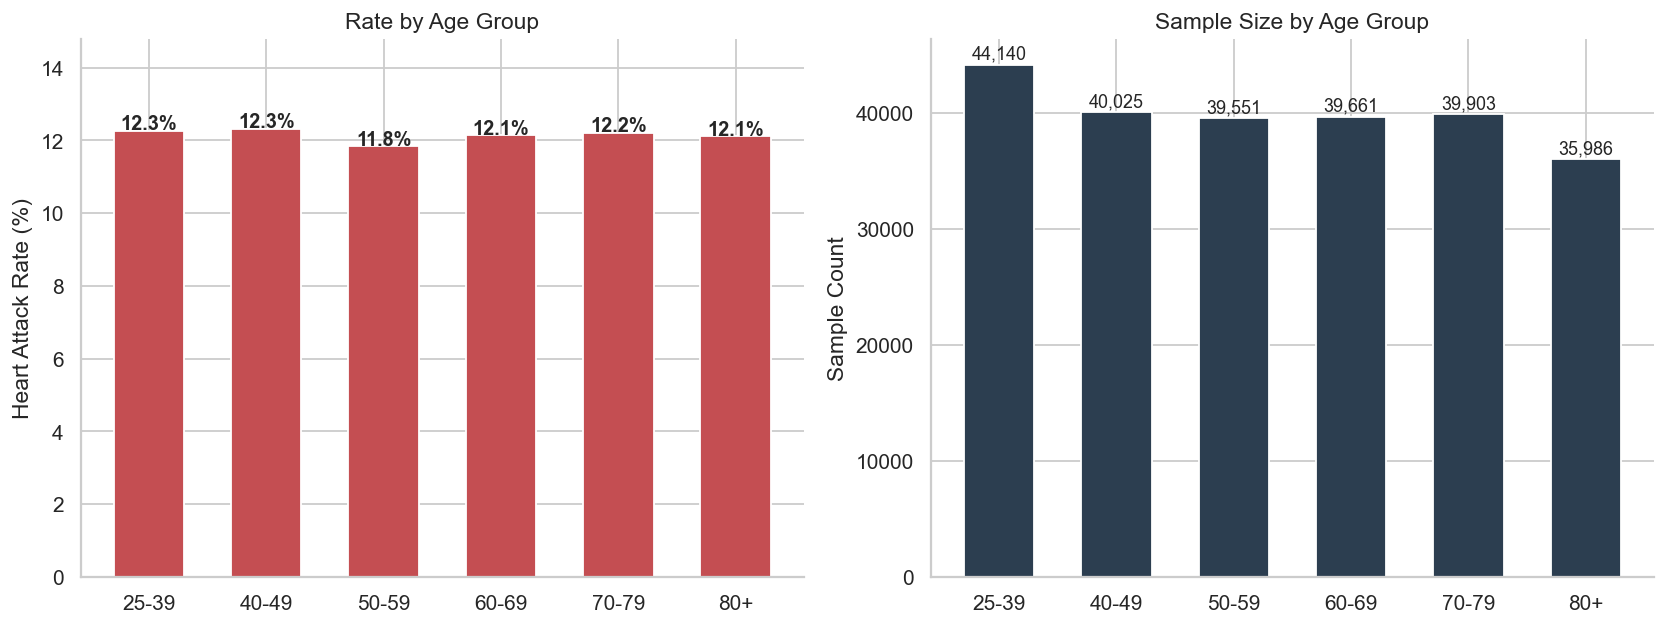

In [82]:
df['Age_Bin'] = pd.cut(df['Age'], bins=[20,40,50,60,70,80,100],
                      labels=['25-39','40-49','50-59','60-69','70-79','80+'])
age_rate = df.groupby('Age_Bin', observed=False)[target].apply(lambda x: (x=='Yes').mean()*100).round(2)
age_n = df.groupby('Age_Bin', observed=False).size()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bars = ax1.bar(age_rate.index, age_rate.values, color=C_YES, edgecolor='white', width=0.6)
bar_text(ax1, bars, age_rate.values, fmt='.1f', suffix='%', fontweight='bold', fontsize=11)
ax1.set(ylabel='Heart Attack Rate (%)', title='Rate by Age Group', ylim=(0, age_rate.max()*1.2))
sns.despine(ax=ax1)

bars2 = ax2.bar(age_n.index, age_n.values, color=C_BLUE, edgecolor='white', width=0.6)
bar_text(ax2, bars2, age_n.values, fmt=',d', offset=500, fontsize=10)
ax2.set(ylabel='Sample Count', title='Sample Size by Age Group')
sns.despine(ax=ax2)

plt.tight_layout(); fig.savefig(f'{OUT}/05_age_stratified.png', dpi=150, bbox_inches='tight'); plt.show()

### 6.2 地理区域分析
五大地理大区 + 城乡差异。

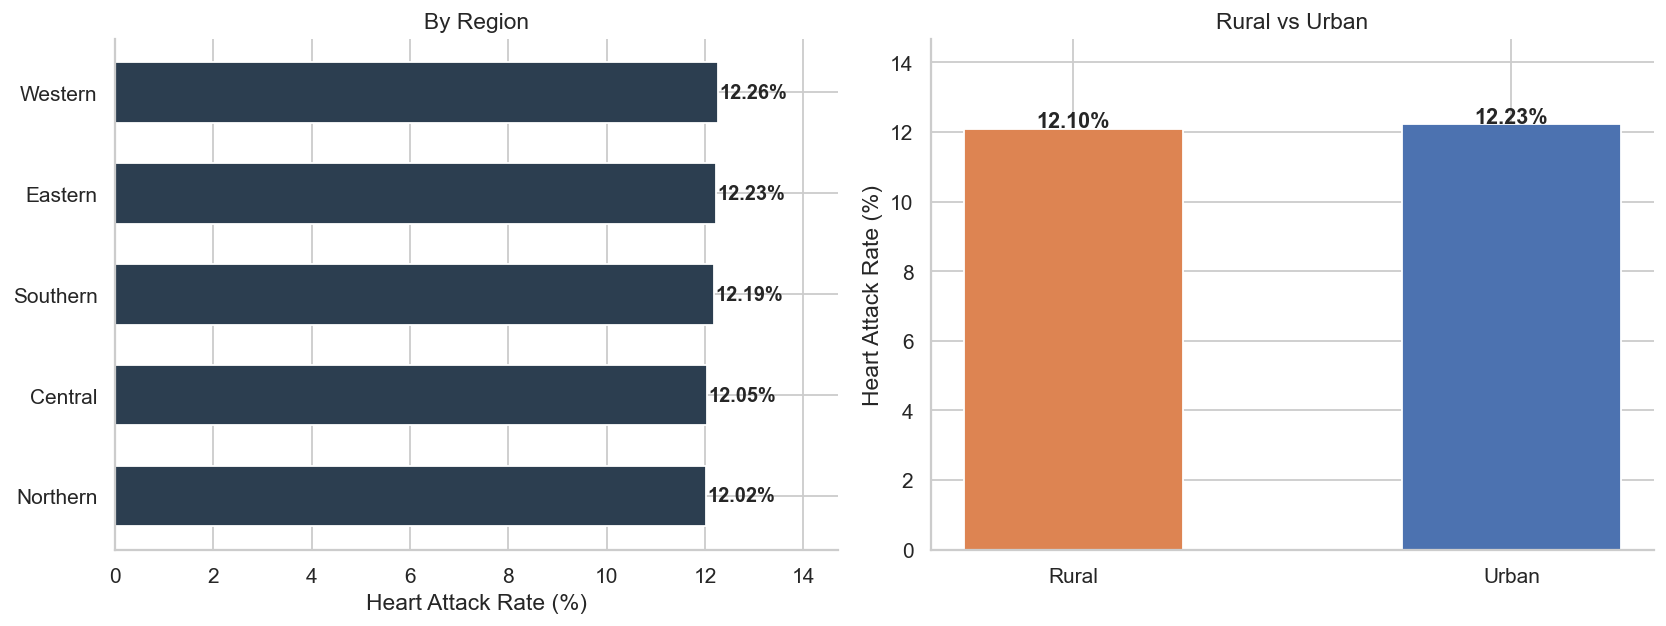

In [83]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

reg_rate = df.groupby('Region')[target].apply(lambda x: (x=='Yes').mean()*100).round(2).sort_values()
ax1.barh(reg_rate.index, reg_rate.values, color=C_BLUE, edgecolor='white', height=0.6)
barh_text(ax1, reg_rate.values, fmt='.2f', suffix='%', fontweight='bold', fontsize=11)
ax1.set(xlabel='Heart Attack Rate (%)', title='By Region', xlim=(0, reg_rate.max()*1.2))
sns.despine(ax=ax1)

ru_rate = df.groupby('Rural_or_Urban')[target].apply(lambda x: (x=='Yes').mean()*100).round(2)
bars = ax2.bar(ru_rate.index, ru_rate.values, color=[C_YELLOW, C_NO], edgecolor='white', width=0.5)
bar_text(ax2, bars, ru_rate.values, fmt='.2f', suffix='%', fontweight='bold', fontsize=12)
ax2.set(ylabel='Heart Attack Rate (%)', title='Rural vs Urban', ylim=(0, ru_rate.max()*1.2))
sns.despine(ax=ax2)

plt.tight_layout(); fig.savefig(f'{OUT}/06_geo.png', dpi=150, bbox_inches='tight'); plt.show()

### 6.3 风险因子交互热图
关键二分类风险因子组合的 Heart Attack 发病率 (%)。

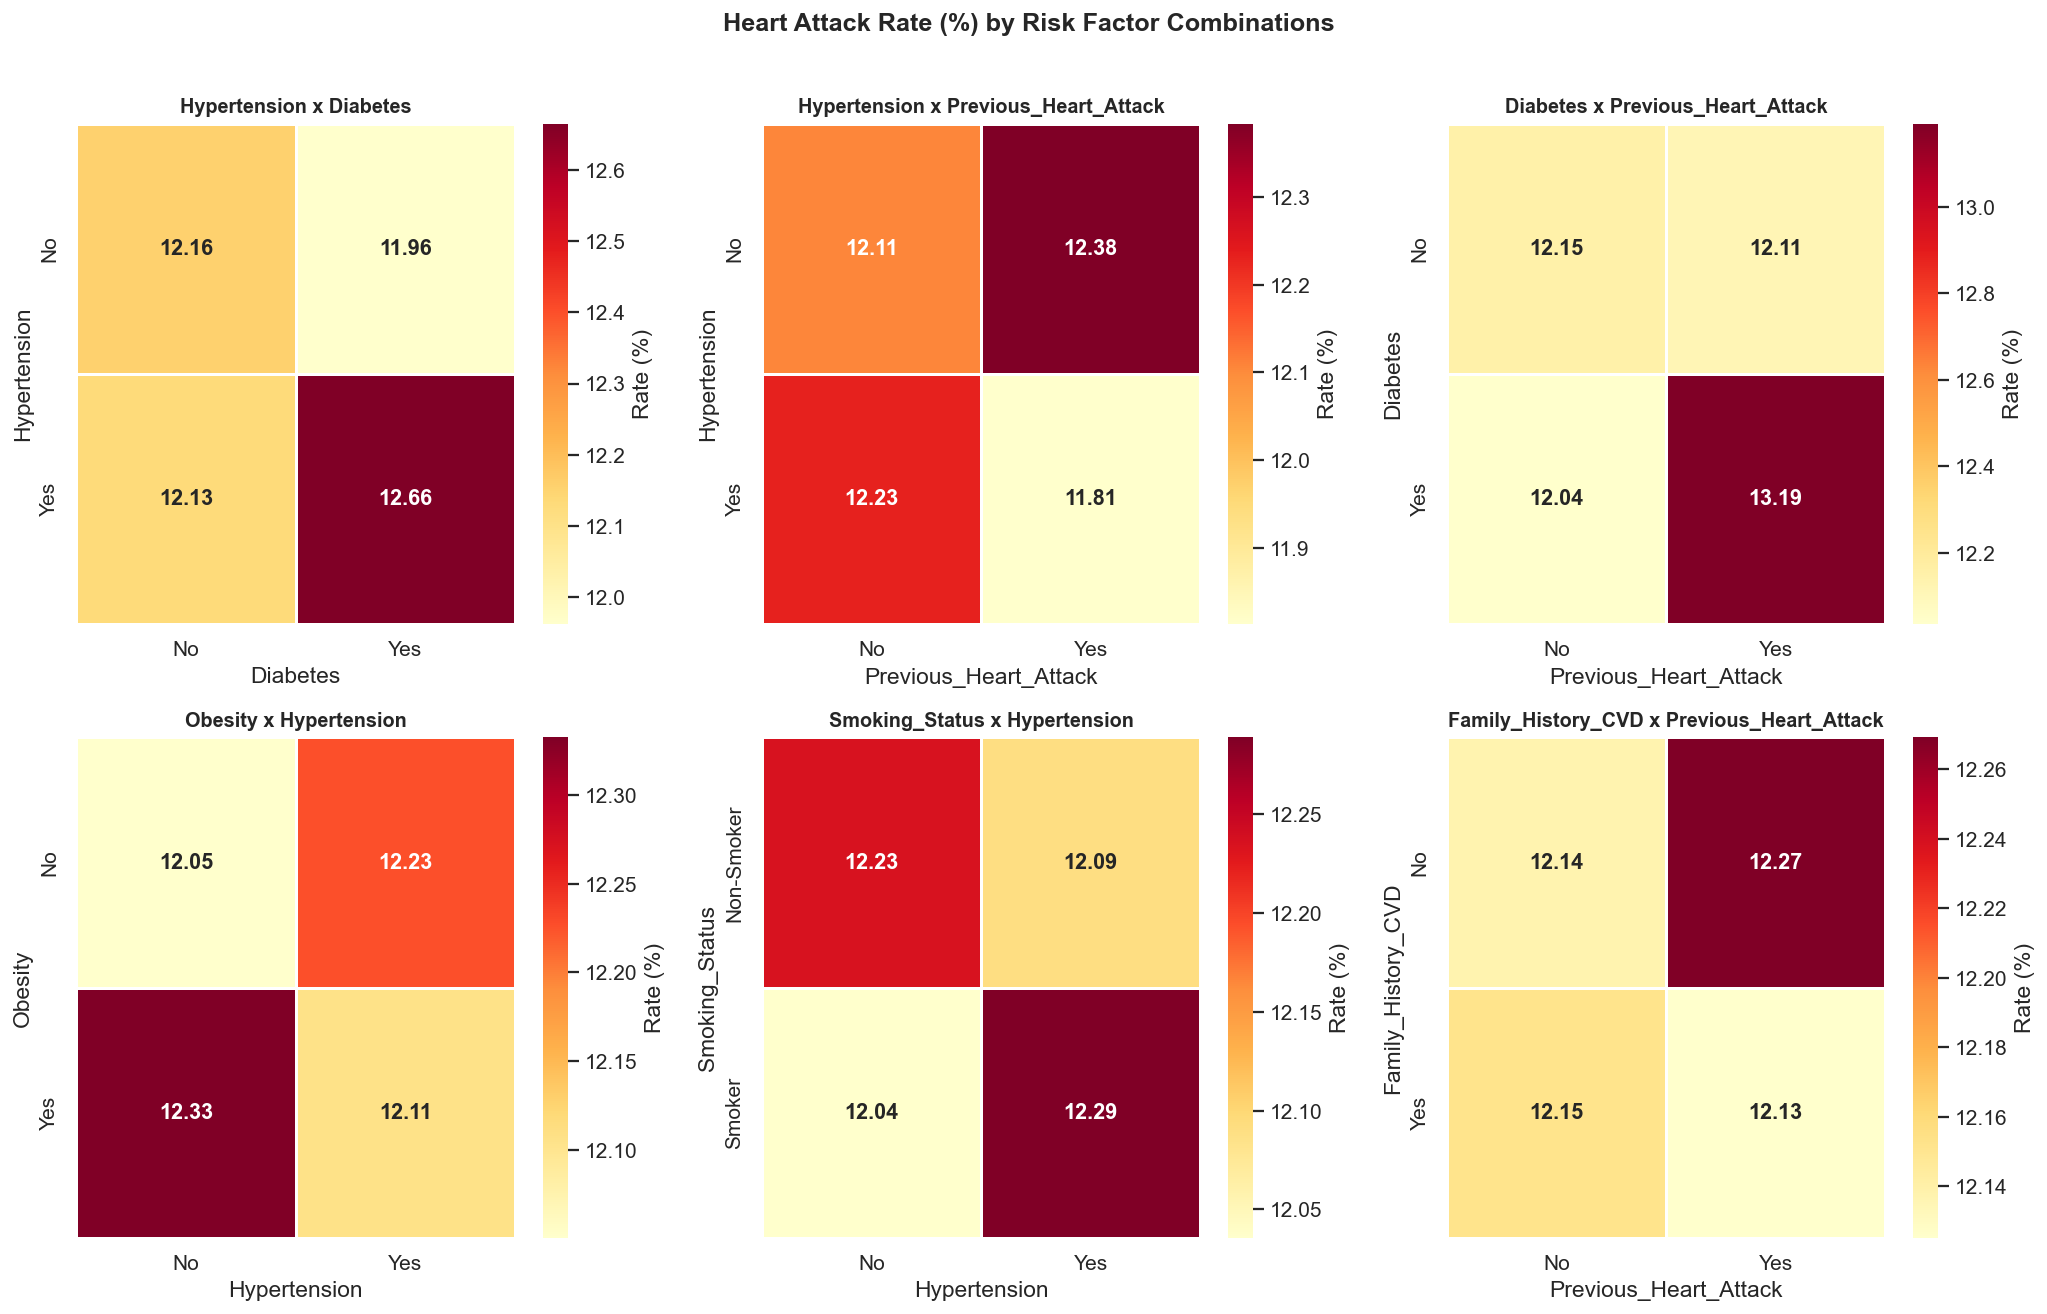

In [84]:
selected = [
    ('Hypertension', 'Diabetes'),
    ('Hypertension', 'Previous_Heart_Attack'),
    ('Diabetes', 'Previous_Heart_Attack'),
    ('Obesity', 'Hypertension'),
    ('Smoking_Status', 'Hypertension'),
    ('Family_History_CVD', 'Previous_Heart_Attack'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, (a, b) in enumerate(selected):
    ax = axes.flat[idx]
    pivot = df.groupby([a, b])[target].apply(lambda x: (x=='Yes').mean()*100).unstack()
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
                cbar_kws={'label': 'Rate (%)'}, linewidths=1.5, annot_kws={'fontsize': 12, 'fontweight': 'bold'})
    ax.set_title(f'{a} x {b}', fontweight='bold', fontsize=11)

fig.suptitle('Heart Attack Rate (%) by Risk Factor Combinations', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); fig.savefig(f'{OUT}/07_risk_interaction.png', dpi=150, bbox_inches='tight'); plt.show()

### 6.4 CVD_Risk_Score 分段与发病率
虽然 CVD_Risk_Score 与 Heart_Attack 无线性相关，但检查是否存在非线性阈值效应。

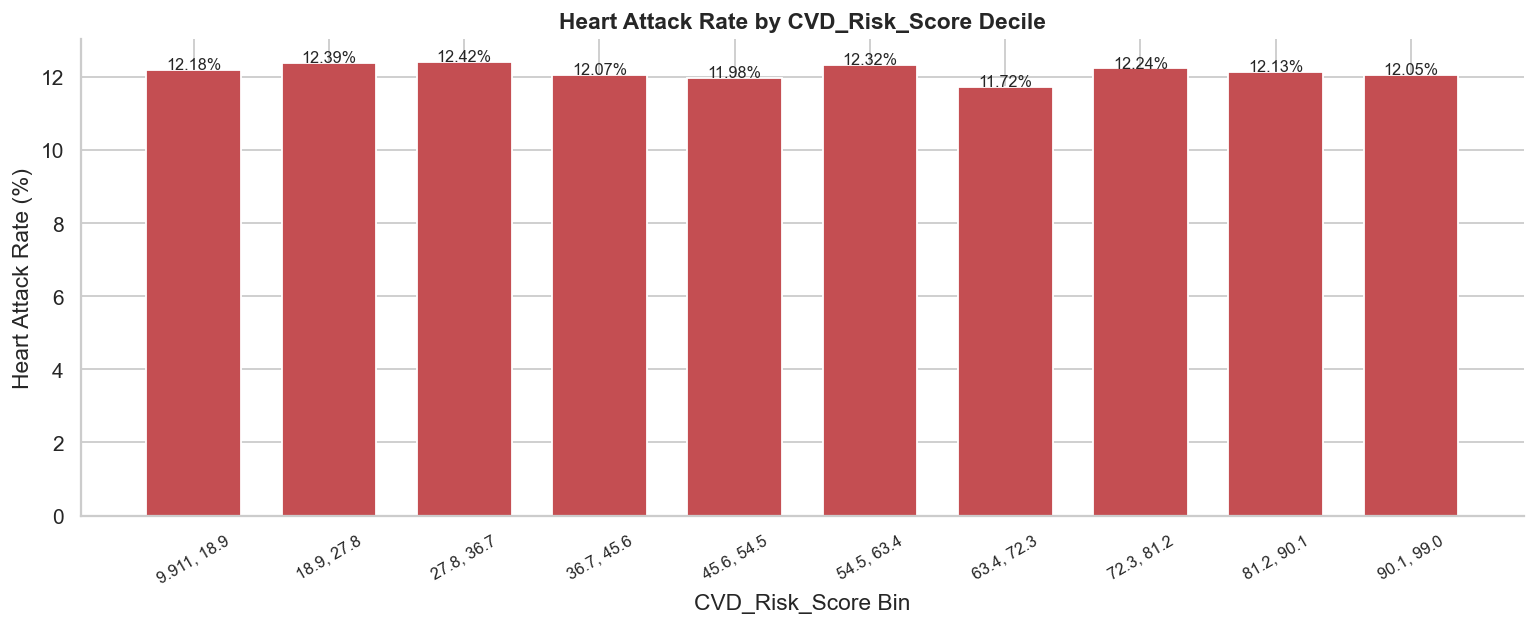

Confirmed: no threshold effect — rate is flat across all score deciles.


In [85]:
df['Risk_Bin'] = pd.cut(df['CVD_Risk_Score'], bins=10)
risk_rate = df.groupby('Risk_Bin', observed=False)[target].apply(lambda x: (x=='Yes').mean()*100)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(risk_rate)), risk_rate.values, color=C_YES, edgecolor='white', width=0.7)
bin_labels = [str(iv).replace('(','').replace(']','') for iv in risk_rate.index]
ax.set_xticks(range(len(risk_rate))); ax.set_xticklabels(bin_labels, rotation=30, fontsize=9)
ax.set(xlabel='CVD_Risk_Score Bin', ylabel='Heart Attack Rate (%)',
       title='Heart Attack Rate by CVD_Risk_Score Decile')
ax.set_title('Heart Attack Rate by CVD_Risk_Score Decile', fontweight='bold')
for i, v in enumerate(risk_rate.values):
    ax.text(i, v+0.02, f'{v:.2f}%', ha='center', fontsize=9)
sns.despine(ax=ax)
plt.tight_layout(); fig.savefig(f'{OUT}/08_risk_score_decile.png', dpi=150, bbox_inches='tight'); plt.show()
print('Confirmed: no threshold effect — rate is flat across all score deciles.')


---
# 模块二：统计分析



## 7. 正态性检验 & 数值变量组间差异

流程：D'Agostino K² 正态性检验 → 正态用 t-test，非正态用 Mann-Whitney U → 计算 Cohen's d 效应量。

In [86]:
results = []
for col in num_cols:
    y=df[df[target]=='Yes'][col]; n=df[df[target]=='No'][col]
    _,p_y=normaltest(y); _,p_n=normaltest(n)
    if p_y>0.05 and p_n>0.05:
        _,p_val=ttest_ind(y,n); method='t-test'
    else:
        _,p_val=mannwhitneyu(y,n,alternative='two-sided'); method='Mann-Whitney U'
    pooled=np.sqrt((y.var(ddof=1)+n.var(ddof=1))/2)
    d=(y.mean()-n.mean())/pooled if pooled>0 else 0
    results.append({'feature':col,'type':'numeric','method':method,
                    'p':p_val,'effect':"Cohen's d",'effect_value':round(d,4),
                    'magnitude':label_mag(d),'sig':label_sig(p_val)})

num_res=pd.DataFrame(results)
num_res

,feature,type,method,p,effect,effect_value,magnitude,sig
0,Age,numeric,Mann-Whitney U,0.555095,Cohen's d,-0.0037,negligible,ns
1,Blood_Pressure,numeric,Mann-Whitney U,0.792498,Cohen's d,0.0016,negligible,ns
2,CVD_Risk_Score,numeric,Mann-Whitney U,0.226748,Cohen's d,-0.0076,negligible,ns


## 8. 分类变量卡方检验 + Cramer's V

In [87]:
cat_results=[]
for col in cat_low:
    ct=pd.crosstab(df[col],df[target])
    chi2,p_val,dof,_=chi2_contingency(ct)
    n_total=ct.sum().sum()
    v=np.sqrt(chi2/(n_total*(min(ct.shape)-1))) if min(ct.shape)>1 else 0
    cat_results.append({'feature':col,'type':'categorical','method':'chi2',
                        'p':p_val,'effect':"Cramer's V",'effect_value':round(v,4),
                        'magnitude':label_mag(v*3),'sig':label_sig(p_val)})

cat_res=pd.DataFrame(cat_results)
cat_res

,feature,type,method,p,effect,effect_value,magnitude,sig
0,Air_Pollution_Exposure,categorical,chi2,0.856768,Cramer's V,0.0011,negligible,ns
1,Alcohol_Consumption,categorical,chi2,0.815818,Cramer's V,0.0005,negligible,ns
2,Cholesterol_Level,categorical,chi2,0.135220,Cramer's V,0.0041,negligible,ns
3,Chronic_Kidney_Disease,categorical,chi2,0.523511,Cramer's V,0.0013,negligible,ns
4,Diabetes,categorical,chi2,0.997899,Cramer's V,0.0000,negligible,ns
5,Diet_Score,categorical,chi2,0.533505,Cramer's V,0.0023,negligible,ns
6,Education_Level,categorical,chi2,0.670321,Cramer's V,0.0021,negligible,ns
7,Employment_Status,categorical,chi2,0.012981,Cramer's V,0.0060,negligible,*
8,Family_History_CVD,categorical,chi2,1.000000,Cramer's V,0.0000,negligible,ns
9,Gender,categorical,chi2,0.533721,Cramer's V,0.0013,negligible,ns


## 9. 汇总 & Bonferroni 校正

Bonferroni 校正：alpha / 检验次数，控制多重比较的 I 类错误。

In [88]:
res_df = pd.concat([num_res, cat_res], ignore_index=True).sort_values('p').reset_index(drop=True)
n = len(res_df); a_bonf = 0.05/n
res_df['bonf_pass'] = res_df['p'].apply(lambda p: 'Yes' if p<a_bonf else 'No')

print(f'Tests: {n}  |  Bonferroni alpha = {a_bonf:.2e}')
print(f'Passed: {res_df["bonf_pass"].value_counts().get("Yes",0)} / {n}')

BG={'Yes':'#D5F5E3','large':'#FADBD8','medium':'#FDEBD0','small':'#FCF3CF'}
MG={'large':'color:#C0392B;font-weight:bold','medium':'color:#E67E22','small':'color:#2980B9','negligible':'color:#7F8C8D'}

res_df.style\
    .apply(lambda r: [f'background-color:{BG.get(r["bonf_pass"],BG.get(r["magnitude"],""))}' if BG.get(r["bonf_pass"],BG.get(r["magnitude"],"")) else '']*len(r), axis=1)\
    .format({'p':'{:.2e}','effect_value':'{:.4f}'})\
    .map(lambda v: MG.get(v,''), subset=['magnitude'])\
    .map(lambda v: 'color:#27AE60;font-weight:bold' if v=='Yes' else 'color:#BDC3C7', subset=['bonf_pass'])\
    .set_properties(**{'white-space':'nowrap','text-align':'center'})\
    .set_table_styles([{'selector':'th','props':[('text-align','center'),('font-weight','bold')]}])


Tests: 26  |  Bonferroni alpha = 1.92e-03
Passed: 0 / 26


,feature,type,method,p,effect,effect_value,magnitude,sig,bonf_pass
0,Employment_Status,categorical,chi2,1.30e-02,Cramer's V,0.0060,negligible,*,No
1,Cholesterol_Level,categorical,chi2,1.35e-01,Cramer's V,0.0041,negligible,ns,No
2,Income_Level,categorical,chi2,2.16e-01,Cramer's V,0.0036,negligible,ns,No
3,CVD_Risk_Score,numeric,Mann-Whitney U,2.27e-01,Cohen's d,-0.0076,negligible,ns,No
4,Obesity,categorical,chi2,2.38e-01,Cramer's V,0.0024,negligible,ns,No
5,Rural_or_Urban,categorical,chi2,3.27e-01,Cramer's V,0.0020,negligible,ns,No
6,Stress_Level,categorical,chi2,3.59e-01,Cramer's V,0.0029,negligible,ns,No
7,Smoking_Status,categorical,chi2,4.97e-01,Cramer's V,0.0014,negligible,ns,No
8,TCM_Use,categorical,chi2,5.18e-01,Cramer's V,0.0013,negligible,ns,No
9,Chronic_Kidney_Disease,categorical,chi2,5.24e-01,Cramer's V,0.0013,negligible,ns,No


## 10. 效应量综合排名图

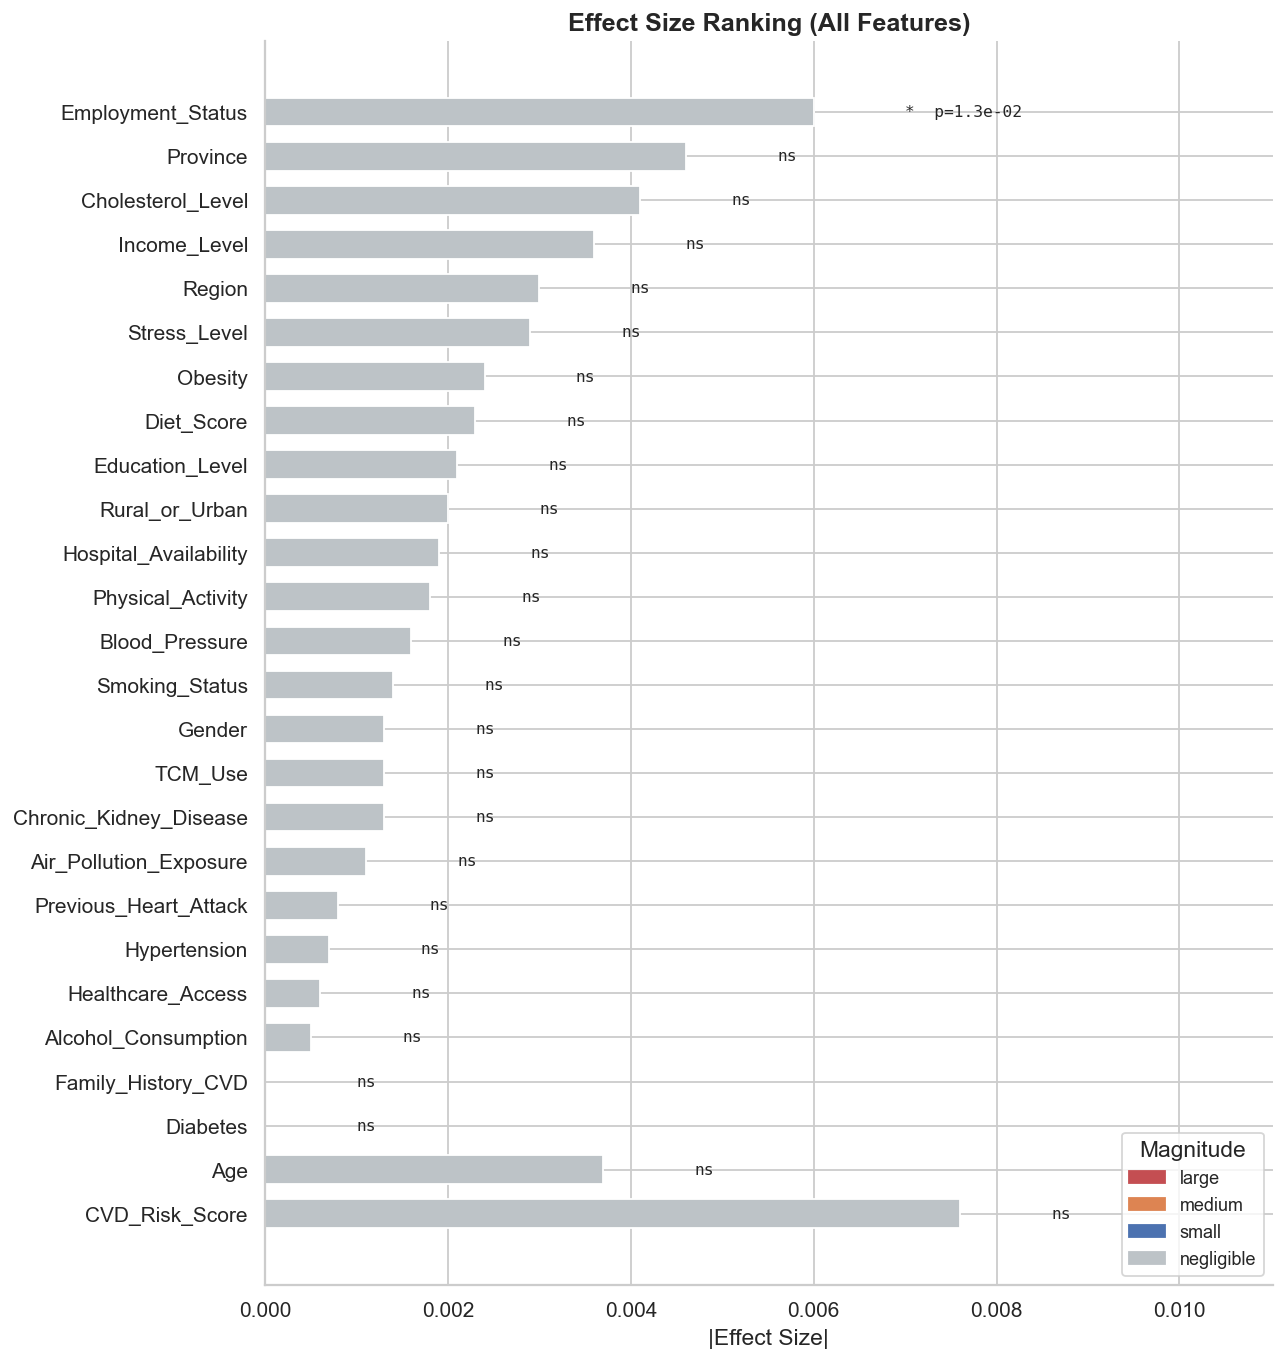

In [89]:
res_sorted = res_df.sort_values('effect_value', ascending=True)
bar_colors = [MAG[m] for m in res_sorted['magnitude']]

fig, ax = plt.subplots(figsize=(10, len(res_sorted) * 0.42 + 1.5))
bars = ax.barh(res_sorted['feature'], res_sorted['effect_value'].abs(),
               color=bar_colors, edgecolor='white', height=0.65)

for bar, sig, p in zip(bars, res_sorted['sig'], res_sorted['p']):
    label = f'{sig}  p={p:.1e}' if sig != 'ns' else 'ns'
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9, fontfamily='monospace')

ax.set(xlabel='|Effect Size|', xlim=(0, res_sorted['effect_value'].abs().max()*1.45),
       title='Effect Size Ranking (All Features)')
ax.set_title('Effect Size Ranking (All Features)', fontsize=14, fontweight='bold')

legend = [Patch(color=v, label=k) for k, v in MAG.items()]
ax.legend(handles=legend, loc='lower right', fontsize=10, title='Magnitude', frameon=True)
sns.despine(ax=ax)

fig.savefig(f'{OUT}/09_effect_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. 导出结果

In [90]:
res_df.to_csv(f'{OUT}/stat_results.csv', index=False, encoding='utf-8-sig')
rate_df.to_csv(f'{OUT}/category_rates.csv', index=False, encoding='utf-8-sig')
summary.to_csv(f'{OUT}/numeric_summary.csv', encoding='utf-8-sig')
print(f'Saved to {OUT}/:')
print('  stat_results.csv    - All statistical test results')
print('  category_rates.csv  - Category-level heart attack rates')
print('  numeric_summary.csv - Numerical variable descriptive stats')
print('  01-09 *.png          - All charts')
print('Done.')

Saved to output/:
  stat_results.csv    - All statistical test results
  category_rates.csv  - Category-level heart attack rates
  numeric_summary.csv - Numerical variable descriptive stats
  01-09 *.png          - All charts
Done.
